In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

In [2]:
# Load dataset
file_path = 'student.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

   student_id first_name   last_name  age                        email  \
0           1    Kerrill   De Cleyne   24          kdecleyne0@furl.net   
1           2    Krissie      Vittet   25          kvittet1@ustream.tv   
2           3   Hugibert       Haugg   21      hhaugg2@theguardian.com   
3           4     Fancie     De Mars   18       fdemars3@parallels.com   
4           5      Micki  O'Dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  Final_score  
0    Venezuela          68             80             15           54  
1     Bulgaria          29             30             60           39  
2  New Zealand          76              0             55           43  
3        China          82             88             90           86  
4        China          77             23             11           37  


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Datatypes
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 10)

Columns:
Index(['student_id', 'first_name', 'last_name', 'age', 'email', 'country',
       'grade_math', 'grade_science', 'grade_english', 'Final_score'],
      dtype='object')

Data Types:
student_id        int64
first_name       object
last_name        object
age               int64
email            object
country          object
grade_math        int64
grade_science     int64
grade_english     int64
Final_score       int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   object
 2   last_name      1000 non-null   object
 3   age            1000 non-null   int64 
 4   email          1000 non-null   object
 5   country        1000 non-null   object
 6   grade_math     1000 non-null   int64 
 7   grade_science  1

In [4]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [5]:
# Check unique student IDs
unique_ids = df['student_id'].nunique()
print("Unique Student IDs:", unique_ids)

# Compare with total rows
print("Total Rows:", len(df))

Unique Student IDs: 1000
Total Rows: 1000


In [6]:
# Function to mask email

def mask_email(email):
    username, domain = email.split('@')
    return username[:2] + '****@' + domain

# Create masked email column

df['masked_email'] = df['email'].apply(mask_email)

# Display original and masked emails
print(df[['email', 'masked_email']].head())

                         email            masked_email
0          kdecleyne0@furl.net         kd****@furl.net
1          kvittet1@ustream.tv       kv****@ustream.tv
2      hhaugg2@theguardian.com  hh****@theguardian.com
3       fdemars3@parallels.com    fd****@parallels.com
4  modowgaine4@livejournal.com  mo****@livejournal.com


In [7]:
# Function to hash email

def hash_email(email):
    return hashlib.sha256(email.encode()).hexdigest()

# Create hashed email column

df['hashed_email'] = df['email'].apply(hash_email)

# Display hashed emails
print(df[['email', 'hashed_email']].head())

                         email  \
0          kdecleyne0@furl.net   
1          kvittet1@ustream.tv   
2      hhaugg2@theguardian.com   
3       fdemars3@parallels.com   
4  modowgaine4@livejournal.com   

                                        hashed_email  
0  26c06b12923e95e63ab50cdfb41c0e91739900817776ef...  
1  46ac4f379c70e96007472da58d7117b75c578377565963...  
2  f05ef8626b2cb36a42220d130021478a26f7c5bf1de9f2...  
3  9a4983240c4a62fc62386f6af99d54a7f6de193e61bd92...  
4  36745378f01b167beb7059937e999fb7c8d726f6ed0c4b...  


In [8]:
# Create restricted dataset
restricted_df = df[[
    'student_id',
    'country',
    'grade_math',
    'grade_science',
    'grade_english',
    'Final_score'
]]

print(restricted_df.head())

   student_id      country  grade_math  grade_science  grade_english  \
0           1    Venezuela          68             80             15   
1           2     Bulgaria          29             30             60   
2           3  New Zealand          76              0             55   
3           4        China          82             88             90   
4           5        China          77             23             11   

   Final_score  
0           54  
1           39  
2           43  
3           86  
4           37  


In [9]:
# Remove personal columns
compliance_df = df.drop(columns=['first_name', 'last_name', 'email'])

print(compliance_df.head())

   student_id  age      country  grade_math  grade_science  grade_english  \
0           1   24    Venezuela          68             80             15   
1           2   25     Bulgaria          29             30             60   
2           3   21  New Zealand          76              0             55   
3           4   18        China          82             88             90   
4           5   24        China          77             23             11   

   Final_score            masked_email  \
0           54         kd****@furl.net   
1           39       kv****@ustream.tv   
2           43  hh****@theguardian.com   
3           86    fd****@parallels.com   
4           37  mo****@livejournal.com   

                                        hashed_email  
0  26c06b12923e95e63ab50cdfb41c0e91739900817776ef...  
1  46ac4f379c70e96007472da58d7117b75c578377565963...  
2  f05ef8626b2cb36a42220d130021478a26f7c5bf1de9f2...  
3  9a4983240c4a62fc62386f6af99d54a7f6de193e61bd92...  
4  367453

In [10]:
# Country distribution
country_counts = df['country'].value_counts()

print(country_counts.head(10))

country
China            174
Indonesia         94
Russia            61
Philippines       57
Portugal          43
Brazil            43
Poland            34
United States     30
France            27
Peru              26
Name: count, dtype: int64


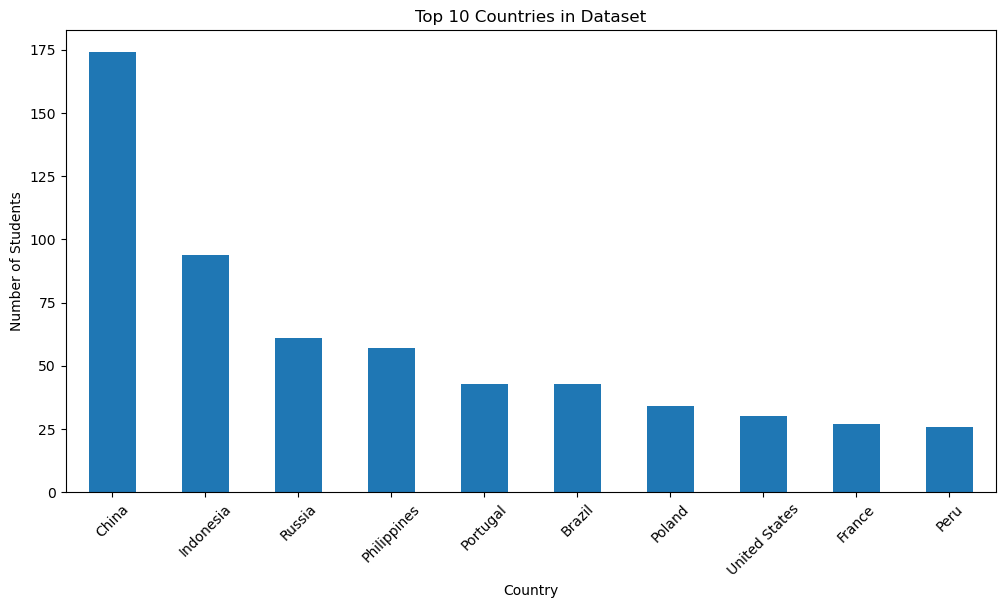

In [11]:
plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar')
plt.title('Top 10 Countries in Dataset')
plt.xlabel('Country')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Missing values
missing_values = df.isnull().sum()
print(missing_values)

student_id       0
first_name       0
last_name        0
age              0
email            0
country          0
grade_math       0
grade_science    0
grade_english    0
Final_score      0
masked_email     0
hashed_email     0
dtype: int64


In [13]:
# Check invalid grades
invalid_math = df[(df['grade_math'] < 0) | (df['grade_math'] > 100)]
invalid_science = df[(df['grade_science'] < 0) | (df['grade_science'] > 100)]
invalid_english = df[(df['grade_english'] < 0) | (df['grade_english'] > 100)]

print("Invalid Math Grades:", len(invalid_math))
print("Invalid Science Grades:", len(invalid_science))
print("Invalid English Grades:", len(invalid_english))

Invalid Math Grades: 0
Invalid Science Grades: 0
Invalid English Grades: 0


In [14]:
# Calculate expected final score

df['calculated_score'] = (
    df['grade_math'] +
    df['grade_science'] +
    df['grade_english']
) / 3

# Round values

df['calculated_score'] = df['calculated_score'].round(0)

# Compare with final score

df['score_match'] = df['calculated_score'] == df['Final_score']

print(df[['Final_score', 'calculated_score', 'score_match']].head())

# Count mismatches
mismatches = df['score_match'].value_counts()
print(mismatches)

   Final_score  calculated_score  score_match
0           54              54.0         True
1           39              40.0        False
2           43              44.0        False
3           86              87.0        False
4           37              37.0         True
score_match
True     653
False    347
Name: count, dtype: int64


In [15]:
# Remove extra spaces

df['country'] = df['country'].str.strip()

# Convert to title case

df['country'] = df['country'].str.title()

print(df['country'].head())

0      Venezuela
1       Bulgaria
2    New Zealand
3          China
4          China
Name: country, dtype: object


In [16]:
print(df.describe())

        student_id          age   grade_math  grade_science  grade_english  \
count  1000.000000  1000.000000  1000.000000    1000.000000    1000.000000   
mean    500.500000    21.536000    50.057000      48.335000      50.634000   
std     288.819436     2.275936    28.868723      29.229114      29.896619   
min       1.000000    18.000000     0.000000       0.000000       0.000000   
25%     250.750000    20.000000    24.000000      24.000000      24.000000   
50%     500.500000    21.000000    51.000000      47.000000      50.000000   
75%     750.250000    23.000000    74.000000      74.000000      77.250000   
max    1000.000000    25.000000   100.000000     100.000000     100.000000   

       Final_score  calculated_score  
count  1000.000000       1000.000000  
mean     49.341000         49.688000  
std      16.801399         16.809438  
min       7.000000          7.000000  
25%      37.000000         38.000000  
50%      49.500000         50.000000  
75%      62.000000      

In [ ]:
correlation = df[[
    'grade_math',
    'grade_science',
    'grade_english',
    'Fi_score'
]].corr()

print(correlation)